# Weekly project 6
Today we will continue work from monday.
We will follow the style of last week.

Weekly project:
- You will need to implement your own k-means algorithm. You are not allowed to use the implementation in `sklearn`.
- It should be able to cluster each of the different figures.
- Extend your k-means so it finds the optimal amount of clusters.
  
## Challenge
- Implement the mean shift clustering algorithm


In [43]:
import numpy as np
import open3d as o3d
import copy
import matplotlib.pyplot as plt

def draw_labels_on_model(pcl, labels):
    """
    Show a point cloud in an Open3D window, coloured by cluster label.

    Args:
        pcl (o3d.geometry.PointCloud): The point cloud to draw. It is copied, so the
            original is not modified.
        labels (np.ndarray): (N,) integer cluster label for each point. Points with a
            negative label (e.g. noise) are drawn black.
    """
    cmap = plt.get_cmap("tab20")
    pcl_temp = copy.deepcopy(pcl)
    max_label = labels.max()
    colors = cmap(labels / (max_label if max_label > 0 else 1))
    colors[labels < 0] = 0
    pcl_temp.colors = o3d.utility.Vector3dVector(colors[:, :3])
    o3d.visualization.draw_geometries([pcl_temp])

d = 4
mesh = o3d.geometry.TriangleMesh.create_tetrahedron().translate((-d, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_octahedron().translate((0, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_icosahedron().translate((d, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_torus().translate((-d, -d, 0))
mesh += o3d.geometry.TriangleMesh.create_mobius(twists=1).translate((0, -d, 0))
mesh += o3d.geometry.TriangleMesh.create_mobius(twists=2).translate((d, -d, 0))

## apply k means on this
point_cloud = mesh.sample_points_uniformly(int(1e3))

## k-means implementation
The algorimth as defined in the lecture slides:

1. **Initialisation**: Draw K centroids. We implemented it with initialisation from a normal distribution with the mean and standard deviation of the point cloud (per axis). This places the centroids in the same region and at the same scale as the data, without depending on its absolute position.
2. **Assignment**: every point is assigned to its nearest centroid (Euclidean distance). We compute the full N×K distance matrix with NumPy broadcasting instead of looping over points, which is much faster.
3. **Update**: every centroid moves to the mean of the points assigned to it. We use `np.bincount` / `np.add.at` to sum the points per cluster without a Python loop. If a centroid gets no points, it keeps its old position. Otherwise the mean of an empty set would be `NaN`.
4. **Convergence**: we stop when the largest centroid movement is below `convergence`, or after `max_runs` iterations as a safety limit.

In [44]:
def kmeans(point_cloud, K, convergence=0.01, max_runs=200, return_avg_dist=False):
    """
    Cluster the points of an Open3D point cloud into K clusters with k-means.

    Args:
        point_cloud (o3d.geometry.PointCloud): The point cloud to cluster (N points).
        K (int): Number of clusters / centroids.
        convergence (float): Stop iterating when no centroid moves more than this
            distance between two iterations. Smaller = more precise but slower.
        max_runs (int): Maximum number of iterations, in case the centroids never
            settle below `convergence`.
        return_avg_dist (bool): If True, also return the average distance from each
            point to its centroid (averaged over clusters). Used to choose K.

    Returns:
        labels (np.ndarray): (N,) index of the cluster each point belongs to.
        avg_dist (float): Only if `return_avg_dist` is True. Mean over clusters of the
            average point-to-centroid distance. Empty clusters are ignored.
    """
    ## Step 1: initialise centroids around the mean, scaled by the std
    points = np.asarray(point_cloud.points)
    mu = points.mean(axis=0)    # (3,)
    sigma = points.std(axis=0)  # (3,)
    centroids = mu + np.random.standard_normal((K, 3)) * sigma

    for runs in range(max_runs):
        ## Step 2: assign each point to its closest centroid
        dists = np.linalg.norm(points[:, None, :] - centroids[None, :, :], axis=2)  # (N, K)
        labels = np.argmin(dists, axis=1)  # (N,)

        ## Step 3: recompute centroids as the mean of their assigned points
        counts = np.bincount(labels, minlength=K)[:, None]   # (K, 1)
        sums = np.zeros_like(centroids)
        np.add.at(sums, labels, points)
        new_centroids = np.where(counts > 0, sums / np.maximum(counts, 1), centroids)

        ## Step 4: stop when no centroid moves more than `convergence`
        shift = np.linalg.norm(new_centroids - centroids, axis=1).max()
        centroids = new_centroids
        if shift < convergence:
            break


    if return_avg_dist:
        ## Average distance from each centroid to the points assigned to it
        point_dists = np.linalg.norm(points - centroids[labels], axis=1)       # (N,)
        counts = np.bincount(labels, minlength=K)
        dist_sums = np.bincount(labels, weights=point_dists, minlength=K)
        avg_dist = np.where(counts > 0, dist_sums / np.maximum(counts, 1), np.nan)  # (K,)
        return labels, np.nanmean(avg_dist)

    return labels


for K in range(1, 10):
    labels = kmeans(point_cloud, K)
    #Uncomment below to see the labels on the model
    #draw_labels_on_model(point_cloud, labels)

## Choosing K: the elbow plot
To see how the average distance depends on K, we run k-means for K = 1…9 and plot the result.

Adding clusters always reduces the distance, since in the extreme every point is its own cluster at distance 0. So we cannot just pick the K with the lowest value. Instead we look for the "elbow", being the K after which more clusters stop helping much. 

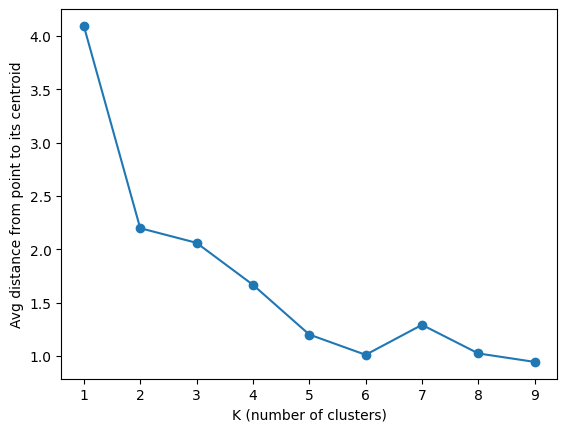

In [52]:
Ks = list(range(1, 10))
avg_dists = []
for K in Ks:
    _, avg_dist = kmeans(point_cloud, K, 0.1, 100, return_avg_dist=True)
    avg_dists.append(avg_dist)

plt.plot(Ks, avg_dists, marker="o")
plt.xlabel("K (number of clusters)")
plt.ylabel("Avg distance from point to its centroid")
plt.xticks(Ks)
plt.show()

As you see in the plot, even though the average distance from centeroids to their cluster in princeple should go down when increasing the number of clusters, there is some significant randomness to this. Rerunning the code confirms that there can be bumps that go up, and that the elbow is not always at 6, where the elbow in theory is most likely to be.

## Finding K automatically
`kmeans_auto` turns the elbow plot into a rule. It increases K one at a time and computes the **relative improvement**

$$\text{rel\_drop} = \frac{d_{K-1} - d_K}{d_{K-1}}$$

When this falls below `min_rel_drop`, the last cluster did not help, so we return the previous K and its labels. This does not depend on the scale of the point cloud. An absolute threshold would have to be retuned if the scene were scaled. The K where the improvement is too small is the first unnecessary one, so the answer is the K before it.

### Pros
- Fully automatic, using only the k-means we already have.
- One intuitive parameter: lower `min_rel_drop` gives more clusters, higher gives fewer.

### Cons
- The threshold is a hand-tuned choice. In our runs the drops before K = 6 were as small as ~14%, while the drop to K = 7 was ~0%, so the threshold must lie in between. That is a fairly narrow window.
- Because k-means is random, the elbow curve is noisy. A bad initialisation for one K can produce a small drop and stop the search too early, or a large one and push it too far.
- It requires running k-means for every K up to the answer, so it costs about K times as much as a single run.

In [55]:
def kmeans_auto(point_cloud, convergence=0.01, max_runs=200, max_K=10, min_rel_drop=0.01, return_K=False):
    """
    Run k-means for K = 1, 2, ... and pick K automatically with the elbow method.

    Adding a cluster always lowers the average point-to-centroid distance, but once
    every real object has its own cluster the improvement becomes small. We stop at
    the first K where the relative improvement drops below `min_rel_drop` and keep
    the previous K.

    Args:
        point_cloud (o3d.geometry.PointCloud): The point cloud to cluster.
        convergence (float): Passed on to `kmeans`; centroid movement threshold.
        max_runs (int): Passed on to `kmeans`; maximum iterations per run.
        max_K (int): Largest K to try. If the elbow is never found, `max_K` is returned.
        min_rel_drop (float): Minimum relative improvement (prev - new) / prev needed to
            accept one more cluster. Lower = more clusters, higher = fewer clusters.
        return_K (bool): If True, also return the chosen K.

    Returns:
        labels (np.ndarray): (N,) cluster labels for the chosen K.
        K (int): Only if `return_K` is True. The chosen number of clusters.
    """
    prev_labels, prev_avg = None, np.nan
    for K in range(1, max_K + 1):
        labels, avg_dist = kmeans(point_cloud, K, convergence=convergence,
                                  max_runs=max_runs, return_avg_dist=True)
        # Stop when going from K-1 to K improves the distance by less than min_rel_drop
        if prev_labels is not None and (prev_avg - avg_dist) / prev_avg < min_rel_drop:
            K, labels = K - 1, prev_labels
            break
        prev_labels, prev_avg = labels, avg_dist

    if return_K:
        return labels, K
    return labels

best_labels, K = kmeans_auto(point_cloud, return_K=True)
print("The best K was:", K)
print("True best K is 6")
draw_labels_on_model(point_cloud, best_labels)

The best K was: 5
True best K is 6


## Results and discussion
This code often gives the correct result (K = 6 with one cluster per shape), but not always. The failures come from the random initialisation, not from the elbow rule itself. When a centroid starts in an empty region or two centroids start on the same shape, k-means converges to a poor local minimum, and the elbow curve gets a bump that misleads `kmeans_auto`.

Possible improvements:
- **Initialise from data points**: pick K random points of the cloud as starting centroids, so no centroid starts in empty space.
- **k-means++**: choose each new starting centroid with probability proportional to its squared distance from the centroids already chosen. This spreads them out over the shapes and is what `sklearn` uses by default.
- **Multiple restarts**: run k-means several times per K and keep the run with the lowest average distance. This smooths the elbow curve and makes the choice of K more reliable.
- **A different criterion for K**, such as the silhouette score, which also rewards clusters that are well separated, not just compact.
- **Mean shift** (the challenge) does not need K at all. It finds the number of clusters from the density of the points, with a bandwidth parameter instead.